In [2]:
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Activation, Dropout, Flatten, Dense
from tensorflow.keras import backend as K

In [3]:
(xtrain,ytrain),(xtest,ytest)=cifar10.load_data()
xtrain=xtrain/255.0
xtest=xtest/255.0
xtrain.shape

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 459s 3us/step


(50000, 32, 32, 3)

In [4]:
model=Sequential([Conv2D(32,(3,3),
                         activation="relu",input_shape=(32,32,3)),
                        MaxPooling2D(pool_size=(2,2)),
                  Conv2D(64,(3,3),activation="relu"),
                  MaxPooling2D(pool_size=(2,2)),
                  Conv2D(128,(3,3),activation="relu"),
                  MaxPooling2D(pool_size=(2,2)),
                  Flatten(),
                  Dense(512,activation="relu"),
                  Dense(10,activation="softmax")
                  ])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [6]:
loss,accuracy=model.evaluate(xtest,ytest)
print(f"loss:{loss},accuracy:{accuracy}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.0990 - loss: 2.3047
loss:2.304720878601074,accuracy:0.0989999994635582


In [7]:
import tensorflow as tf
from tensorflow.keras import  layers,models
import matplotlib.pyplot as plt

In [10]:
xtrain=xtrain/255.0
xtest=xtest/255.0

In [11]:
class_names=["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]

In [12]:
model=models.Sequential()
model.add(layers.Conv2D(32,(3,3),
activation="relu",input_shape=(32,32,3)))
model.add(layers. MaxPooling2D((2,2)))
model.add(layers.Flatten())
model.add(layers.Dense(64,activation="relu"))
model.add(layers.Dense(10,activation="softmax"))

In [13]:
model.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=['accuracy'])

In [19]:
f=model.fit(xtrain,ytrain,epochs=15)

Epoch 1/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.3886 - loss: 1.7184
Epoch 2/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.3974 - loss: 1.6874
Epoch 3/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4084 - loss: 1.6589
Epoch 4/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4153 - loss: 1.6360
Epoch 5/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4230 - loss: 1.6168
Epoch 6/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4287 - loss: 1.5991
Epoch 7/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4363 - loss: 1.5837
Epoch 8/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4422 - loss: 1.5701
Epoch 9/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4477 - loss: 1.5563
Epoch 10/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4500 - loss: 1.5475
Epoch 11/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4535 - loss: 1.5374
Epoch 12/15
1563/1563 ━━━━━━━━

In [20]:
p=model.predict(xtest)
p

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([[1.7726017e-02, 1.7137106e-01, 1.0162929e-01, ..., 1.1537504e-02,
        3.5028536e-02, 2.2474676e-02],
       [6.5360360e-02, 1.9402497e-01, 7.5259741e-04, ..., 2.1087881e-03,
        5.2426827e-01, 2.0934452e-01],
       [1.5578507e-01, 1.7188849e-01, 1.1631798e-03, ..., 4.2667537e-04,
        5.5535322e-01, 1.1102396e-01],
       ...,
       [8.3681224e-03, 4.7611399e-03, 9.5513582e-02, ..., 5.0299484e-02,
        8.2865499e-02, 1.5221873e-03],
       [1.3143104e-02, 9.5370924e-03, 9.3088560e-02, ..., 8.1911892e-02,
        2.1001808e-02, 1.8995963e-02],
       [1.5285342e-02, 3.5904204e-03, 8.9518689e-02, ..., 4.5597756e-01,
        8.9253318e-03, 7.8269187e-03]], dtype=float32)

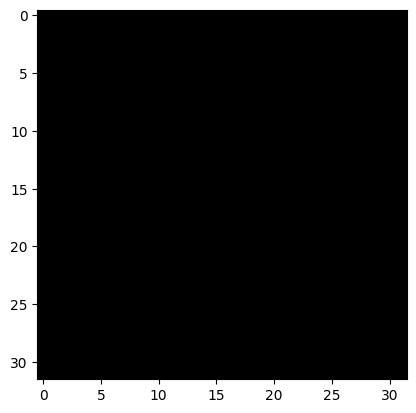

In [21]:
import numpy as np
index=5
plt.imshow(xtest[index])
class_names[np.argmax(p[index])]
plt.show()

In [22]:
from tensorflow.keras.preprocessing import image

In [24]:
img=image.load_img("airoplane_resize.png",target_size=(32,32))
img_arr=image.img_to_array(img)/255.0
img_arr=tf.expand_dims(img_arr,axis=0)
p=model.predict(img_arr)
print(class_names[np.argmax(p)])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
airplane
